## Importing necessary modules and data

In [11]:
import pickle
import pandas as pd
import sys
sys.path.append(r"D:\HopeAI\Assignments\MyModules")
import evaluate_clustering_algos as clust_algos

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme('notebook')


In [4]:
filename=r"D:\HopeAI\Assignments\ML and DS Capstone\4. Feature Selection\dataset_unscaled.pkl"
dataset_unscaled = pickle.load(open(filename,'rb'))
dataset_unscaled


,Market Cap,Total_Annual_Return,Std_Monthly_Return,Max_Drawdown,Pos_Days_Pct,Avg_Daily_TR,Avg_Volume,Volume_Spike_Pct,Months_Pos_Pct,Beta_vs_NIFTY,Corr_with_NIFTY
0,2994291081216,84.785613,14.186042,22.867706,52.674897,2.352871,1.861417e+07,8.196721,63.636364,1.598832,0.426155
1,2994291081216,-37.685498,19.560876,68.997003,45.714286,3.742656,1.120364e+07,7.317073,54.545455,1.850348,0.457929
2,2994291081216,-14.119856,15.492383,34.794663,53.469388,1.581010,6.074467e+06,6.097561,54.545455,1.649825,0.597262
3,2994291081216,117.329561,8.526439,28.780005,56.680162,2.889061,1.295658e+07,8.064516,81.818182,1.912510,0.332076
4,2994291081216,78.500944,26.632411,43.633455,54.693878,6.293391,1.475299e+07,11.382114,36.363636,2.142941,0.478182
...,...,...,...,...,...,...,...,...,...,...,...
497,2532097654784,56.564122,11.196238,36.623083,52.000000,3.742075,2.239159e+07,9.163347,63.636364,0.670407,0.529060
498,2532097654784,84.735387,6.752821,12.734524,57.085020,6.545712,2.143325e+07,10.080645,72.727273,0.849918,0.476230
499,2532097654784,-44.808074,6.336069,47.492937,47.368421,4.864650,1.479087e+07,3.629032,27.272727,1.083736,0.691712
500,2532097654784,20.203754,6.272716,14.238744,48.360656,3.161690,1.015820e+07,6.938776,54.545455,1.108324,0.554158


## Scaling and Clustering

In [ ]:
# Find Best Scaler and Clustering Algo

summary_table, all_df_scores = clust_algos.run_all_scalers_unified(clust_algos, dataset_unscaled, no_clust=3, rand_state=10, top_n=3, verbose=True)
summary_table


Scores for Dataset scaled with RobustScaler

                     Num_Clusters     Silhouette  DaviesBouldin  \
KMeans                        3.0         0.2400         1.3196   
Agglomerative                 3.0         0.2964         1.1780   
GaussianMixture               3.0         0.1347         2.1783   
SpectralClustering            3.0         0.2338         1.2949   
Birch                         3.0         0.4729         0.8610   
DBSCAN                        1.0  Not available  Not available   
OPTICS                        1.0  Not available  Not available   
AffinityPropagation          44.0         0.1280         1.3525   
MeanShift                     8.0         0.3322         1.1067   

                    CalinskiHarabasz  
KMeans                       85.0425  
Agglomerative                92.9221  
GaussianMixture              57.0916  
SpectralClustering           74.0287  
Birch                        90.9201  
DBSCAN                 Not available  
OPTICS     

,Scaler,Best_Silhouette_Algo,Best_Silhouette,Best_CalinskiHarabasz_Algo,Best_CalinskiHarabasz,Best_DaviesBouldin_Algo,Best_DaviesBouldin
0,RobustScaler,Birch,0.4729,Agglomerative,92.9221,Birch,0.8610
1,MinMaxScaler,MeanShift,0.3593,KMeans,92.6810,Birch,1.3659
2,StandardScaler,MeanShift,0.3378,KMeans,77.2507,MeanShift,1.1099


In [7]:
# From result above,RobustScaler with Birch Algo gives best results.
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
dataset_scaled = scaler.fit_transform(dataset_unscaled)
filename="scaler.pkl"
pickle.dump(scaler, open(filename,'wb'))
dataset_scaled


array([[-0.01585248,  1.78455141,  2.00138868, ...,  0.5       ,
         1.20055983, -0.34570011],
       [-0.01585248, -1.3764908 ,  3.5835421 , ...,  0.        ,
         1.67576192, -0.20341348],
       [-0.01585248, -0.76824948,  2.38592752, ...,  0.        ,
         1.29690244,  0.42052859],
       ...,
       [-0.17661286, -1.56032813, -0.30935448, ..., -1.5       ,
         0.22735895,  0.84348681],
       [-0.17661286,  0.1176605 , -0.32800309, ...,  0.        ,
         0.27381386,  0.22750579],
       [-0.17661286,  0.30776083, -0.14732615, ...,  1.        ,
         0.17744486,  0.13139078]], shape=(484, 11))

## Dimensionality Reduction - PCA

In [ ]:
pca = PCA().fit(dataset_scaled)
pca_exp_var = pca.explained_variance_ratio_
exp_cum = pca_exp_var.cumsum()
# Choose minimal n_components where cumulative variance >= threshold
threshold = 0.80
pca_comp = next(i for i, total_var in enumerate(exp_cum, start=1) if total_var >= threshold)
print(f'{pca_comp} components are required to explain {exp_cum[pca_comp-1]*100:.2f}% variance of data')


5 components are required to explain 85.36% variance of data


In [15]:

pca = PCA(n_components = pca_comp)
X = pca.fit_transform(dataset_scaled)
filename="pca.pkl"
pickle.dump(pca, open(filename,'wb'))


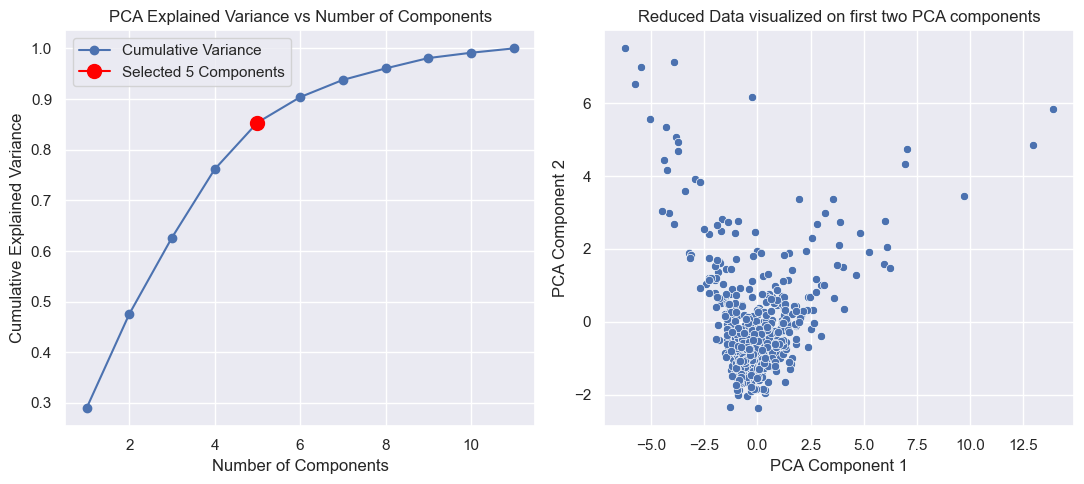

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(11, 5))  # two rows, one column

# First subplot: Cumulative Explained Variance
axs[0].plot(range(1, len(pca_exp_var) + 1), exp_cum, marker='o', label='Cumulative Variance')
# Highlight the chosen component with a red marker
axs[0].plot(pca_comp, exp_cum[pca_comp - 1], marker='o', color='red', markersize=10, label=f'Selected {pca_comp} Components')
axs[0].set_xlabel('Number of Components')
axs[0].set_ylabel('Cumulative Explained Variance')
axs[0].set_title('PCA Explained Variance vs Number of Components')
axs[0].legend()

# Second subplot: Scatterplot of first two PCA components
sns.scatterplot(x=X[:, 0], y=X[:, 1], ax=axs[1])
axs[1].set_xlabel('PCA Component 1')
axs[1].set_ylabel('PCA Component 2')
axs[1].set_title('Reduced Data visualized on first two PCA components')

plt.tight_layout()
plt.show()


## Clustering

## Birch Algorithm used based on above results

In [12]:
from sklearn.cluster import Birch
birch_clust = Birch()
labels = birch_clust.fit_predict(X)
pd.Series(labels).value_counts()


1    367
0     71
2     46
Name: count, dtype: int64

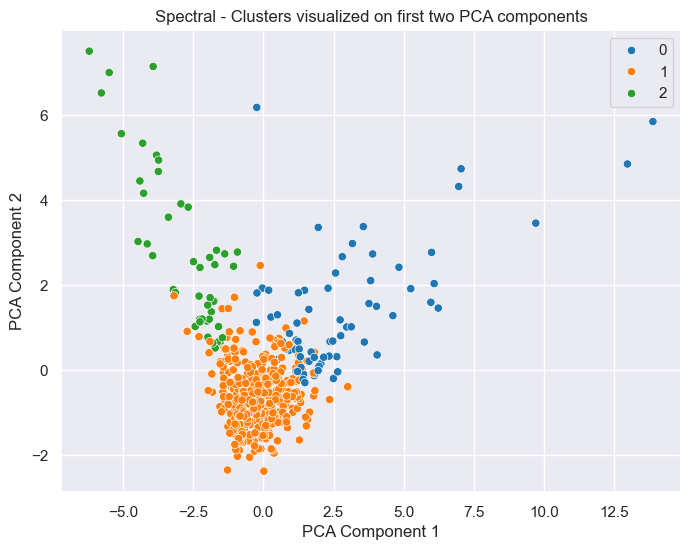

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette='tab10')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Spectral - Clusters visualized on first two PCA components')
plt.show()


In [ ]:

supervised=dataset_unscaled
supervised['Cluster_group']=labels

filename=r'D:\HopeAI\Assignments\ML and DS Capstone\4. Feature Selection\dataset_reduced.pkl'
dataset_reduced = pickle.load(open(filename,'rb'))
dataset_reduced['Cluster_group']=labels
supervised


,Market Cap,Total_Annual_Return,Std_Monthly_Return,Max_Drawdown,Pos_Days_Pct,Avg_Daily_TR,Avg_Volume,Volume_Spike_Pct,Months_Pos_Pct,Beta_vs_NIFTY,Corr_with_NIFTY,Cluster_group
0,2994291081216,84.785613,14.186042,22.867706,52.674897,2.352871,1.861417e+07,8.196721,63.636364,1.598832,0.426155,1
1,2994291081216,-37.685498,19.560876,68.997003,45.714286,3.742656,1.120364e+07,7.317073,54.545455,1.850348,0.457929,0
2,2994291081216,-14.119856,15.492383,34.794663,53.469388,1.581010,6.074467e+06,6.097561,54.545455,1.649825,0.597262,0
3,2994291081216,117.329561,8.526439,28.780005,56.680162,2.889061,1.295658e+07,8.064516,81.818182,1.912510,0.332076,1
4,2994291081216,78.500944,26.632411,43.633455,54.693878,6.293391,1.475299e+07,11.382114,36.363636,2.142941,0.478182,0
...,...,...,...,...,...,...,...,...,...,...,...,...
497,2532097654784,56.564122,11.196238,36.623083,52.000000,3.742075,2.239159e+07,9.163347,63.636364,0.670407,0.529060,0
498,2532097654784,84.735387,6.752821,12.734524,57.085020,6.545712,2.143325e+07,10.080645,72.727273,0.849918,0.476230,1
499,2532097654784,-44.808074,6.336069,47.492937,47.368421,4.864650,1.479087e+07,3.629032,27.272727,1.083736,0.691712,0
500,2532097654784,20.203754,6.272716,14.238744,48.360656,3.161690,1.015820e+07,6.938776,54.545455,1.108324,0.554158,1


In [22]:
dataset_reduced


,Stock,Sector,Industry,Market Cap,Year,Total_Annual_Return,Std_Monthly_Return,Max_Drawdown,Pos_Days_Pct,Avg_Daily_TR,Avg_Volume,Volume_Spike_Pct,Months_Pos_Pct,Beta_vs_NIFTY,Corr_with_NIFTY,Cluster_group
0,ADANIENT,Energy,Thermal Coal,2994291081216,2014,84.785613,14.186042,22.867706,52.674897,2.352871,1.861417e+07,8.196721,63.636364,1.598832,0.426155,1
1,ADANIENT,Energy,Thermal Coal,2994291081216,2015,-37.685498,19.560876,68.997003,45.714286,3.742656,1.120364e+07,7.317073,54.545455,1.850348,0.457929,0
2,ADANIENT,Energy,Thermal Coal,2994291081216,2016,-14.119856,15.492383,34.794663,53.469388,1.581010,6.074467e+06,6.097561,54.545455,1.649825,0.597262,0
3,ADANIENT,Energy,Thermal Coal,2994291081216,2017,117.329561,8.526439,28.780005,56.680162,2.889061,1.295658e+07,8.064516,81.818182,1.912510,0.332076,1
4,ADANIENT,Energy,Thermal Coal,2994291081216,2018,78.500944,26.632411,43.633455,54.693878,6.293391,1.475299e+07,11.382114,36.363636,2.142941,0.478182,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,WIPRO,Technology,Information Technology Services,2532097654784,2020,56.564122,11.196238,36.623083,52.000000,3.742075,2.239159e+07,9.163347,63.636364,0.670407,0.529060,0
498,WIPRO,Technology,Information Technology Services,2532097654784,2021,84.735387,6.752821,12.734524,57.085020,6.545712,2.143325e+07,10.080645,72.727273,0.849918,0.476230,1
499,WIPRO,Technology,Information Technology Services,2532097654784,2022,-44.808074,6.336069,47.492937,47.368421,4.864650,1.479087e+07,3.629032,27.272727,1.083736,0.691712,0
500,WIPRO,Technology,Information Technology Services,2532097654784,2023,20.203754,6.272716,14.238744,48.360656,3.161690,1.015820e+07,6.938776,54.545455,1.108324,0.554158,1


#### Understanding what each cluster means

In [23]:
# Grouped means for each feature by Cluster_group:
means = supervised.groupby('Cluster_group').mean()
means


,Market Cap,Total_Annual_Return,Std_Monthly_Return,Max_Drawdown,Pos_Days_Pct,Avg_Daily_TR,Avg_Volume,Volume_Spike_Pct,Months_Pos_Pct,Beta_vs_NIFTY,Corr_with_NIFTY
Cluster_group,,,,,,,,,,,
0,4.075828e+12,15.268354,13.754917,39.956243,50.654197,11.154608,2.992964e+07,6.237312,55.185659,1.348190,0.603015
1,4.466189e+12,25.404491,7.237796,20.295251,51.216310,17.389378,6.317645e+06,6.062096,58.607877,0.917474,0.461791
2,3.002022e+12,18.906525,8.153177,23.644472,50.784738,109.778630,8.265714e+05,6.400556,56.916996,0.960476,0.522429


**Clusters Category Definition**

| Cluster | Category Name          | Description                                                        |
|:--------:|:----------------------:|:------------------------------|
| 0        | High Risk               |High volatility & drawdown|
| 1        | Low Risk          |Low volatility & drawdown|
| 2        | Medium Risk              |Moderate risk, active trading|


In [24]:
dataset_reduced['Categories'] = dataset_reduced['Cluster_group'].map({0:'High Risk', 1:'Low Risk', 2:'Medium Risk'})



In [25]:
filename='supervised.pkl'
pickle.dump(supervised, open(filename,'wb'))
filename='full_dataset.pkl'
pickle.dump(dataset_reduced, open(filename,'wb'))
